# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [10]:
# Download dataset
data_dir = kagglehub.dataset_download(
    "pavansubhasht/ibm-hr-analytics-attrition-dataset"
)

csv_path = os.path.join(data_dir, "WA_Fn-UseC_-HR-Employee-Attrition.csv")
df = pd.read_csv(csv_path)

# Simpan sebagai raw dataset
df.to_csv("namadataset_raw/ibm_hr_attrition_raw.csv", index=False)

print("Dataset raw berhasil disimpan")

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Dataset raw berhasil disimpan


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

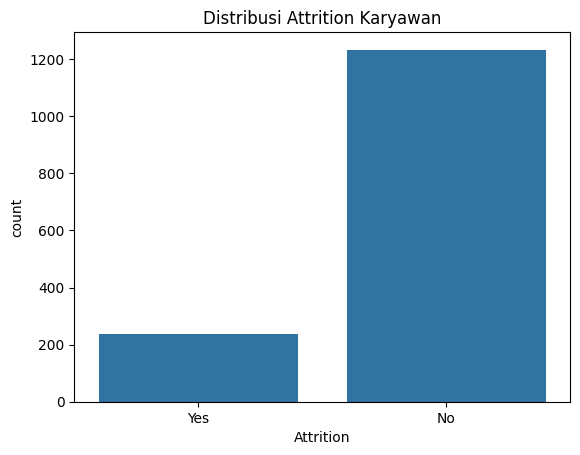

In [3]:
sns.countplot(x="Attrition", data=df)
plt.title("Distribusi Attrition Karyawan")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [15]:
%%writefile preprocessing/automate_Nama-siswa.py
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

def preprocess_data(input_path, output_path):
    df = pd.read_csv(input_path)

    # Drop kolom tidak informatif
    cols_to_drop = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]
    df.drop(columns=cols_to_drop, inplace=True)

    # Handle missing values
    for col in df.columns:
        if df[col].dtype in ["int64", "float64"]:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

    # Drop duplicate
    df.drop_duplicates(inplace=True)

    # Encoding
    df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})
    df = pd.get_dummies(df, drop_first=True)

    # Outlier handling (IQR)
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = np.clip(df[col], lower, upper)

    # Scaling
    X = df.drop("Attrition", axis=1)
    y = df["Attrition"]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    final_df = pd.DataFrame(X_scaled, columns=X.columns)
    final_df["Attrition"] = y.values

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    final_df.to_csv(output_path, index=False)

    print("Preprocessing otomatis selesai")
    print("Shape akhir:", final_df.shape)

if __name__ == "__main__":
    preprocess_data(
        "namadataset_raw/ibm_hr_attrition_raw.csv",
        "preprocessing/namadataset_preprocessing/ibm_hr_attrition_preprocessed.csv"
    )

Overwriting preprocessing/automate_Nama-siswa.py
